In [1]:
%matplotlib widget

# Plot comparisons

In [22]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error
sys.path.insert(1, '../src')

from showStitched import showStitchedModels
from FDEM1D import FDEM1D
plt.style.use('bmh')

In [9]:
model_true = np.load('models/model_3DChannel_topo.npy')
model_true[:,:,2] = model_true[:,:,2]*0
model_true[:,:,3:] = model_true[:,:,3:]*1000

model_true_grid = np.load('models/model_true_grid_topo.npy')

model_LCI = np.load('models/model_LCI_Channel_topo.npy')
model_PW = np.load('models/model_PW_Channel_topo.npy')

model_LCI_grid = np.load('models/model_LCI_Channel_grid_topo.npy')
model_PW_grid = np.load('models/model_PW_Channel_grid_topo.npy')

# Plot Lines

/tmp/ipykernel_3060751/3972226875.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(5, figsize=(6,7), sharex=True)
/tmp/ipykernel_3060751/3972226875.py:20: RuntimeWarning: invalid value encountered in divide
  abs_diff = np.abs((model_LCI_grid[l].T - model_true_grid[l].T)/model_true_grid[l].T)*100
/tmp/ipykernel_3060751/3972226875.py:37: RuntimeWarning: invalid value encountered in divide
  abs_diff = np.abs((model_PW_grid[l].T - model_true_grid[l].T)/model_true_grid[l].T)*100


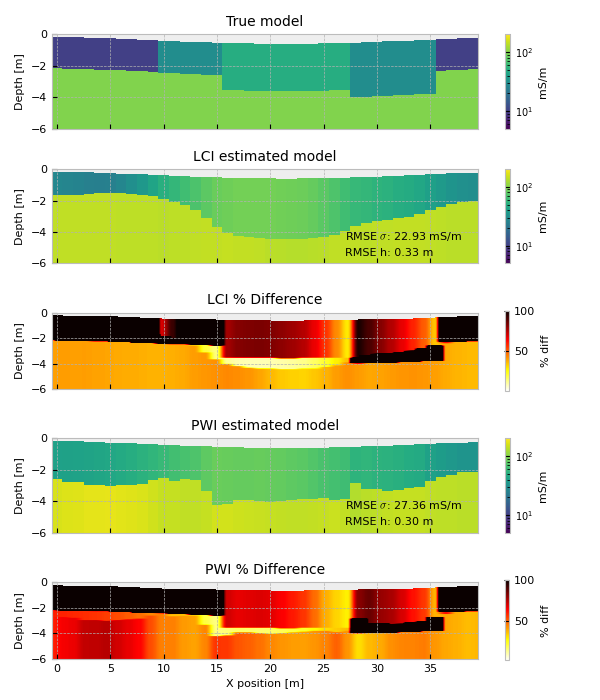

In [47]:
fig, ax = plt.subplots(5, figsize=(6,7), sharex=True)

l = 30
fs = 8
fs2 = 10
cmap = 'hot_r'

showStitchedModels(model_true[:,l,:], zMax= 6, cMin=5, cMax=200, ax=ax[0], label='mS/m')
ax[0].set_title('True model', fontsize=fs2)
ax[0].set_ylabel('Depth [m]', fontsize=fs)
ax[0].tick_params(labelsize=fs)

showStitchedModels(model_LCI[l,:,:], zMax= 6, cMin=5, cMax=200, ax=ax[1], label='mS/m')
ax[1].set_title('LCI estimated model', fontsize=fs2)
ax[1].set_ylabel('Depth [m]', fontsize=fs)
ax[1].text(27,-4.5, 'RMSE $\sigma$: %2.2f' %root_mean_squared_error(model_true[:,l,2:], model_LCI[l,:,2:]) + ' mS/m', fontsize=fs)
ax[1].text(27,-5.5, 'RMSE h: %2.2f' %root_mean_squared_error(model_true[:,l,:2], model_LCI[l,:,:2]) + ' m', fontsize=fs)
ax[1].tick_params(labelsize=fs)

abs_diff = np.abs((model_LCI_grid[l].T - model_true_grid[l].T)/model_true_grid[l].T)*100
abs_diff[abs_diff ==0] = np.NaN
c2 = ax[2].imshow(abs_diff, extent=([-1, 40,-6,0]), cmap=cmap, aspect=1.2,  vmin=1, vmax=100)
cb =fig.colorbar(c2, ax=ax[2], label='mS/m', shrink=0.85)
cb.ax.tick_params(labelsize=fs)
cb.ax.set_ylabel('% diff', fontsize=fs)
ax[2].set_title('LCI % Difference', fontsize=fs2)
ax[2].set_ylabel('Depth [m]', fontsize=fs)
ax[2].tick_params(labelsize=fs)

showStitchedModels(model_PW[l,:,:], zMax= 6, cMin=5, cMax=200, ax=ax[3], label='mS/m')
ax[3].set_title('PWI estimated model', fontsize=fs2)
ax[3].set_ylabel('Depth [m]', fontsize=fs)
ax[3].text(27,-4.5, 'RMSE $\sigma$: %2.2f' %root_mean_squared_error(model_true[:,l,2:], model_PW[l,:,2:]) + ' mS/m', fontsize=fs)
ax[3].text(27,-5.5, 'RMSE h: %2.2f' %root_mean_squared_error(model_true[:,l,:2], model_PW[l,:,:2]) + ' m', fontsize=fs)
ax[3].tick_params(labelsize=fs)

abs_diff = np.abs((model_PW_grid[l].T - model_true_grid[l].T)/model_true_grid[l].T)*100
abs_diff[abs_diff==0] = np.NaN
c2 = ax[4].imshow(abs_diff, extent=([-1, 40,-6,0]), cmap=cmap, aspect=1.2,  vmin=1, vmax=100 )
cb =fig.colorbar(c2, ax=ax[4], label='mS/m', shrink=0.85)
cb.ax.set_ylabel('% diff', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[4].set_title('PWI % Difference', fontsize=fs2)
ax[4].set_ylabel('Depth [m]', fontsize=fs)
ax[4].set_xlabel('X position [m]', fontsize=fs)
ax[4].tick_params(labelsize=fs)

#fig.suptitle('Line Y: '+str( l) +' m')

plt.tight_layout()
plt.savefig('figures/Channel_topo_Line30.eps', format='eps')

In [12]:
# Plot Maps

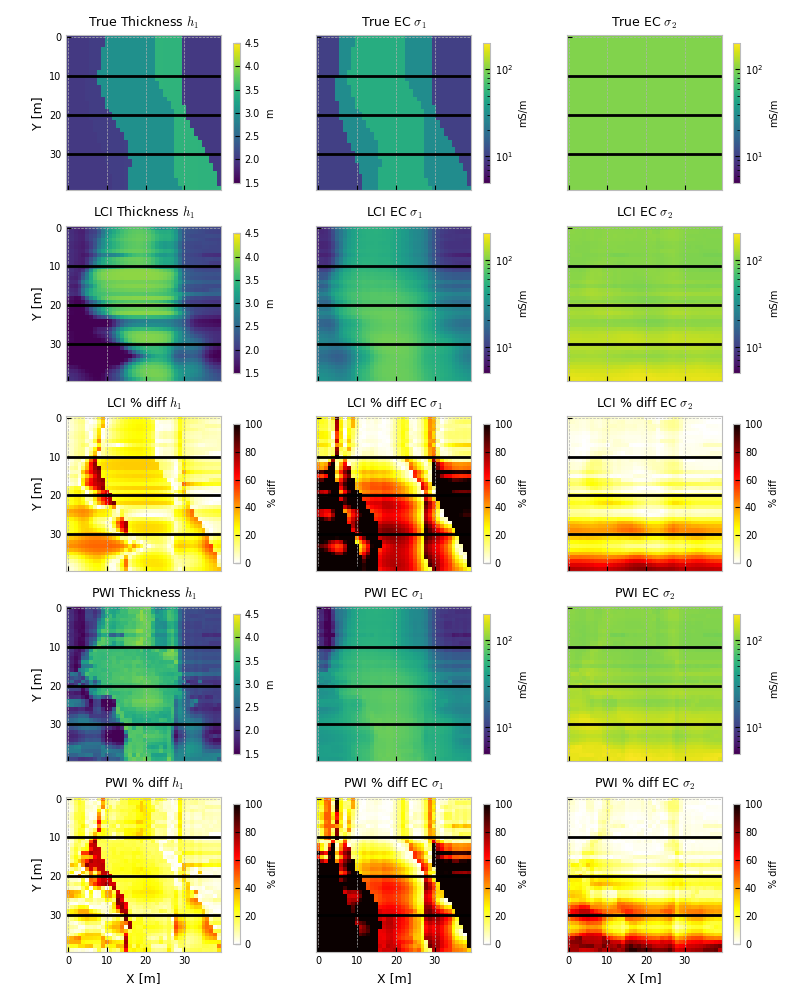

In [18]:
fig, ax = plt.subplots(5,3, figsize=(8,10), sharex=True, sharey=True)

s=0.9
fs=7
fs2=9
vmin=5
vmax=200
cmap='hot_r'

c1 = ax[0,0].imshow(model_true[:,:,1].T, vmin=1.5, vmax=4.5)
cb = fig.colorbar(c1, ax=ax[0,0],  shrink=s, )
cb.ax.set_ylabel('m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[0,0].tick_params(labelsize=fs)
ax[0,0].set_title('True Thickness $h_1$', fontsize=fs2)
ax[0,0].set_ylabel('Y [m]', fontsize=fs2)
ax[0,0].plot([0,39], [10,10],'k')
ax[0,0].plot([0,39], [20,20],'k')
ax[0,0].plot([0,39], [30,30],'k')

c1 = ax[1,0].imshow(model_LCI[:,:,1], vmin=1.5, vmax=4.5)
cb = fig.colorbar(c1, ax=ax[1,0], shrink=s)
ax[1,0].set_title('LCI Thickness $h_1$', fontsize=fs2)
ax[1,0].set_ylabel('Y [m]', fontsize=fs2)
ax[1,0].plot([0,39], [10,10],'k')
ax[1,0].plot([0,39], [20,20],'k')
ax[1,0].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[1,0].tick_params(labelsize=fs)

c1 = ax[2,0].imshow((np.abs(model_true[:,:,1].T - model_LCI[:,:,1])/model_true[:,:,1].T)*100, vmin=0, vmax=100, cmap=cmap)
cb = fig.colorbar(c1, ax=ax[2,0], shrink=s)
ax[2,0].set_title('LCI % diff $h_1$', fontsize=fs2)
ax[2,0].set_ylabel('Y [m]', fontsize=fs2)
ax[2,0].plot([0,39],[10,10],'k')
ax[2,0].plot([0,39],[20,20], 'k')
ax[2,0].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('% diff', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[2,0].tick_params(labelsize=fs)

c1 = ax[3,0].imshow(model_PW[:,:,1], vmin=1.5, vmax=4.5)
cb = fig.colorbar(c1, ax=ax[3,0],  shrink=s)
ax[3,0].set_title('PWI Thickness $h_1$', fontsize=fs2)
ax[3,0].set_ylabel('Y [m]', fontsize=fs2)
ax[3,0].plot([0,39], [10,10],'k')
ax[3,0].plot([0,39], [20,20],'k')
ax[3,0].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[3,0].tick_params(labelsize=fs)

c1 = ax[4,0].imshow((np.abs(model_true[:,:,1].T - model_PW[:,:,1])/model_true[:,:,1].T)*100, vmin=0, vmax=100, cmap=cmap)
cb = fig.colorbar(c1, ax=ax[4,0], shrink=s)
ax[4,0].set_title('PWI % diff $h_1$', fontsize=fs2)
ax[4,0].set_ylabel('Y [m]', fontsize=fs2)
ax[4,0].set_xlabel('X [m]', fontsize=fs2)
ax[4,0].plot([0,39], [10,10],'k')
ax[4,0].plot([0,39], [20,20],'k')
ax[4,0].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('% diff', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[4,0].tick_params(labelsize=fs)

c2 = ax[0,1].imshow(model_true[:,:,3].T, vmin =vmin, vmax=vmax, norm='log')
cb = fig.colorbar(c2, ax=ax[0,1],  shrink=s)
ax[0,1].set_title('True EC $\sigma_1$', fontsize=fs2)
ax[0,1].plot([0,39], [10,10],'k')
ax[0,1].plot([0,39], [20,20],'k')
ax[0,1].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('mS/m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[0,1].tick_params(labelsize=fs)

c2 = ax[1,1].imshow(model_LCI[:,:,3], vmin =vmin, vmax=vmax, norm='log')
cb = fig.colorbar(c2, ax=ax[1,1],  shrink=s)
ax[1,1].set_title('LCI EC $\sigma_1$', fontsize=fs2)
ax[1,1].plot([0,39], [10,10],'k')
ax[1,1].plot([0,39], [20,20],'k')
ax[1,1].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('mS/m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[1,1].tick_params(labelsize=fs)

c1 = ax[2,1].imshow((np.abs(model_true[:,:,3].T - model_LCI[:,:,3])/model_true[:,:,3].T)*100, vmin=0, vmax=100, cmap=cmap)
cb = fig.colorbar(c1, ax=ax[2,1],  shrink=s)
ax[2,1].set_title('LCI % diff EC $\sigma_1$', fontsize=fs2)
ax[2,1].plot([0,39], [10,10],'k')
ax[2,1].plot([0,39], [20,20],'k')
ax[2,1].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('% diff', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[2,1].tick_params(labelsize=fs)

c2 = ax[3,1].imshow(model_PW[:,:,3], vmin =vmin, vmax=vmax, norm='log')
cb = fig.colorbar(c2, ax=ax[3,1],  shrink=s)
ax[3,1].set_title('PWI EC $\sigma_1$', fontsize=fs2)
ax[3,1].plot([0,39], [10,10],'k')
ax[3,1].plot([0,39], [20,20],'k')
ax[3,1].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('mS/m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[3,1].tick_params(labelsize=fs)

c1 = ax[4,1].imshow((np.abs(model_true[:,:,3].T - model_PW[:,:,3])/model_true[:,:,3].T)*100, vmin=0, vmax=100, cmap=cmap)
cb = fig.colorbar(c1, ax=ax[4,1],  shrink=s)
ax[4,1].set_title('PWI % diff EC $\sigma_1$', fontsize=fs2)
ax[4,1].set_xlabel('X [m]', fontsize=fs2)
ax[4,1].plot([0,39], [10,10],'k')
ax[4,1].plot([0,39], [20,20],'k')
ax[4,1].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('% diff', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[4,1].tick_params(labelsize=fs)

c3 = ax[0,2].imshow(model_true[:,:,4].T, vmin =vmin, vmax=vmax, norm='log')
cb = fig.colorbar(c3, ax=ax[0,2],  shrink=s)
ax[0,2].set_title('True EC $\sigma_2$', fontsize=fs2)
ax[0,2].plot([0,39], [10,10],'k')
ax[0,2].plot([0,39], [20,20],'k')
ax[0,2].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('mS/m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[0,2].tick_params(labelsize=fs)

c3 = ax[1,2].imshow(model_LCI[:,:,4], vmin =vmin, vmax=vmax, norm='log')
cb = fig.colorbar(c3, ax=ax[1,2],  shrink=s)
ax[1,2].set_title('LCI EC $\sigma_2$', fontsize=fs2)
ax[1,2].plot([0,39], [10,10], 'k')
ax[1,2].plot([0,39], [20,20],'k')
ax[1,2].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('mS/m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[1,2].tick_params(labelsize=fs)

c1 = ax[2,2].imshow((np.abs(model_true[:,:,4].T - model_LCI[:,:,4])/model_true[:,:,4].T)*100, vmin=0, vmax=100, cmap=cmap)
cb = fig.colorbar(c1, ax=ax[2,2],  shrink=s)
ax[2,2].set_title('LCI % diff EC $\sigma_2$', fontsize=fs2)
ax[2,2].plot([0,39], [10,10],'k')
ax[2,2].plot([0,39], [20,20],'k')
ax[2,2].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('% diff', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[2,2].tick_params(labelsize=fs)

c3 = ax[3,2].imshow(model_PW[:,:,4], vmin =vmin, vmax=vmax, norm='log')
cb  = fig.colorbar(c3, ax=ax[3,2],  shrink=s)
ax[3,2].set_title('PWI EC $\sigma_2$', fontsize=fs2)
ax[3,2].plot([0,39], [10,10],'k')
ax[3,2].plot([0,39], [20,20],'k')
ax[3,2].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('mS/m', fontsize=fs)
cb.ax.tick_params(labelsize=fs)
ax[3,2].tick_params(labelsize=fs)

c1 = ax[4,2].imshow((np.abs(model_true[:,:,4].T - model_PW[:,:,4])/model_true[:,:,4].T)*100, vmin=0, vmax=100, cmap=cmap)
cb = fig.colorbar(c1, ax=ax[4,2], shrink=s)
ax[4,2].set_title('PWI % diff EC $\sigma_2$', fontsize=fs2)
ax[4,2].set_xlabel('X [m]', fontsize=fs2)
ax[4,2].plot([0,39], [10,10],'k')
ax[4,2].plot([0,39], [20,20],'k')
ax[4,2].plot([0,39], [30,30],'k')
cb.ax.set_ylabel('% diff', fontsize=fs, )
cb.ax.tick_params(labelsize=fs)
ax[4,2].tick_params(labelsize=fs)

plt.tight_layout()
plt.savefig('figures/Channel_topo_maps.eps', format='eps')

In [19]:
# Plot data comparison

In [20]:
data_true = np.load('data/data_3DChannel_nosort_topo.npy')
data_true = data_true.reshape((40, 40, 18))

In [31]:
# Forward the true model with 1D forward

data_1D = np.zeros_like(data_true)

for i in range(0,40):
    for j in range(0,40):
        data_1D[i,j] = FDEM1D(model_true[i,j,3:]/1000, model_true[i,j,1], height=0.3)

# Forward the LCI estimated model 

data_LCI = np.zeros_like(data_true)

for i in range(0,40):
    for j in range(0,40):
        data_LCI[i,j] = FDEM1D(model_LCI[i,j,3:]/1000, model_LCI[i,j,1], height=0.3)
        
# Forward the PWI estimated model

data_PWI = np.zeros_like(data_true)

for i in range(0,40):
    for j in range(0,40):
        data_PWI[i,j] = FDEM1D(model_PW[i,j,3:]/1000, model_PW[i,j,1], height=0.3)

In [52]:
def PlotDatas(data_true, data_1D, data_LCI, data_PWI, l=10):

    keys = ['HCP $s=2m$ Quadrature', 'HCP $s=4m$ Quadrature', 'HCP $s=8m$ Quadrature',
            'PRP $s=2.1m$ Quadrature', 'PRP $s=4.1m$ Quadrature', 'PRP $s=8.1m$ Quadrature',
            'VCP $s=2m$ Quadrature', 'VCP $s=2m$ Quadrature', 'VCP $s=2m$ Quadrature',
            'HCP $s=2m$ In-Phase', 'HCP $s=4m$ In-Phase', 'HCP $s=8m$ In-Phase',
            'PRP $s=2m$ In-Phase', 'PRP $s=4m$ In-Phase', 'PRP $s=8m$ In-Phase',
            'VCP $s=2m$ In-Phase', 'VCP $s=4m$ In-Phase', 'VCP $s=8m$ In-Phase',]

    fs = 8
    
    fig, axs = plt.subplots(12,3, figsize=(10,10), layout='constrained', sharex=True,)
    
    ax = axs.ravel()
    k = 0
    for i in range(6):
        for j in range(3):
            ii = i * 6
            ax[ii+j].plot(data_true[l,:,k]*1000, 'r', label='True', )
            ax[ii+j].plot(data_1D[:,l,k]*1000, 'k', label ='1D', )
            ax[ii+j].plot(data_LCI[l,:,k]*1000, '--b', label = 'LCI', )
            ax[ii+j].plot(data_PWI[l,:,k]*1000, '-.g', label = 'PWI', )

            ax[ii+j+3].plot(np.abs((data_1D[:,l,k] - data_true[l,:,k])/data_true[l,:,k])*100, 'k', label ='1D')
            ax[ii+j+3].plot(np.abs((data_LCI[l,:,k] - data_true[l,:,k])/data_true[l,:,k])*100, '--b', label = 'LCI')
            ax[ii+j+3].plot(np.abs((data_PWI[l,:,k] - data_true[l,:,k])/data_true[l,:,k])*100, '-.g',  label = 'PWI')

            ax[ii+j].set_title(keys[k], fontsize=fs+1)
            ax[ii+j].tick_params(labelsize=fs)
            ax[ii+j+3].set_title('Difference %', fontsize=fs+1)
            ax[ii+j+3].tick_params(labelsize=fs)
            
            k +=1
    
    axs[11,0].set_xlabel('X [m]', fontsize=fs)
    axs[11,1].set_xlabel('X [m]', fontsize=fs)
    axs[11,2].set_xlabel('X [m]', fontsize=fs)

    axs[0,0].set_ylabel('[ppt]', fontsize=fs)
 #   axs[1,0].set_ylabel('[ppt]', fontsize=fs)
    axs[2,0].set_ylabel('[ppt]', fontsize=fs)
 #   axs[3,0].set_ylabel('[ppt]', fontsize=fs)
    axs[4,0].set_ylabel('[ppt]', fontsize=fs)
 #   axs[5,0].set_ylabel('[ppt]', fontsize=fs)
    axs[6,0].set_ylabel('[ppt]', fontsize=fs)
 #   axs[7,0].set_ylabel('[ppt]', fontsize=fs)
    axs[8,0].set_ylabel('[ppt]', fontsize=fs)
 #   axs[9,0].set_ylabel('[ppt]', fontsize=fs)
    axs[10,0].set_ylabel('[ppt]', fontsize=fs)
 #   axs[11,0].set_ylabel('[ppt]', fontsize=fs)
    axs[0,2].legend( bbox_to_anchor=(1.01, 1.01), fontsize=fs)
    plt.show()
#plt.tight_layout()

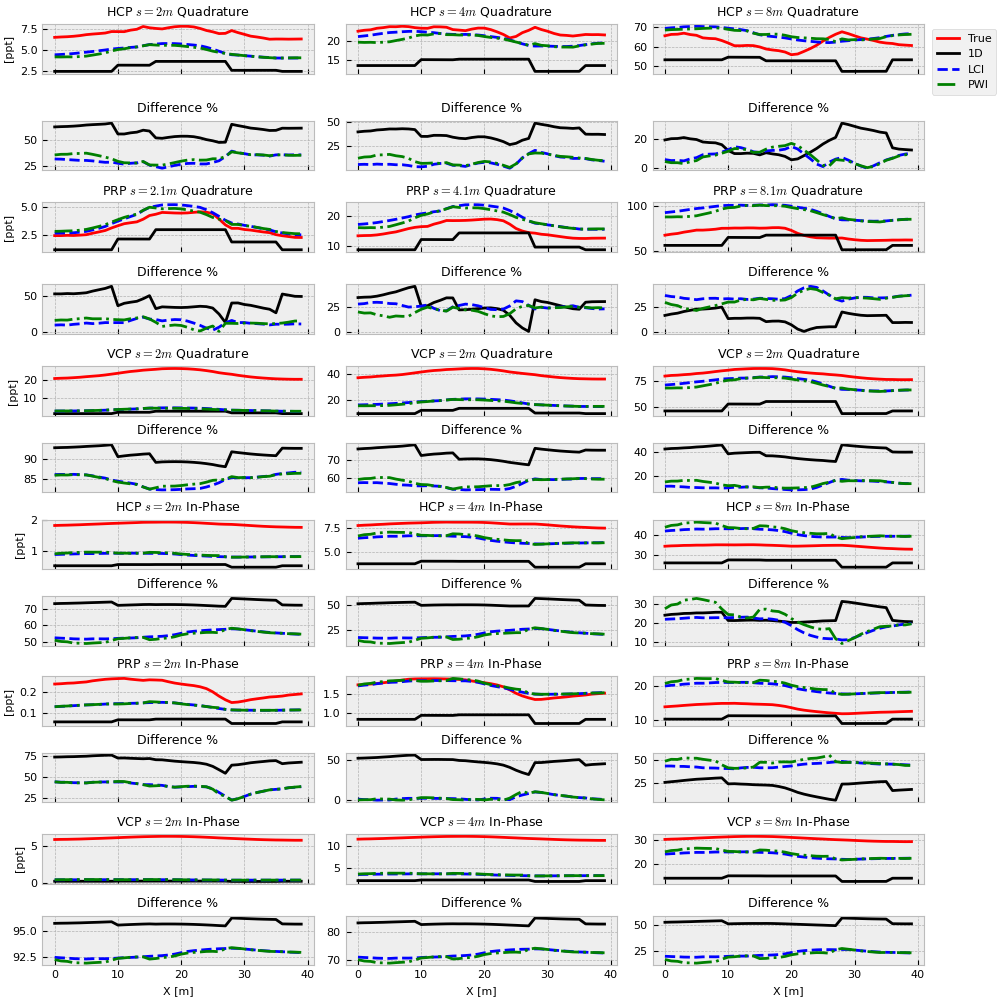

12/08/25 - 16:15:28 - matplotlib.backends.backend_ps - WARNING - The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [54]:
PlotDatas(data_true, data_1D, data_LCI, data_PWI, l=30)
plt.savefig('figures/datafit_channel_topo_Line30.eps', format='eps')